# Churn Prediction: Model Comparison
### ANN vs Logistic Regression vs XGBoost

Same train/test split (80/20, stratified, `random_state=42`), same 25-feature encoded dataset (IBM Telco Customer Churn), same held-out 1,409-row test set (374 actual churners / 1,035 non-churners) across all three models. Numbers below are pulled directly from each model's own notebook run — not re-estimated.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 4)

## 1. Test Set Metrics

In [7]:
metrics = {
    'ANN':                  {'Accuracy': 0.7516, 'Precision': 0.52, 'Recall': 0.75, 'F1': 0.61, 'ROC-AUC': 0.8369},
    'Logistic Regression':  {'Accuracy': 0.7395, 'Precision': 0.5060, 'Recall': 0.7834, 'F1': 0.6149, 'ROC-AUC': 0.8412},
    'XGBoost (Tuned)':      {'Accuracy': 0.7424, 'Precision': 0.5093, 'Recall': 0.8075, 'F1': 0.6246, 'ROC-AUC': 0.8463},
}

comp_df = pd.DataFrame(metrics).T
comp_df

,Accuracy,Precision,Recall,F1,ROC-AUC
ANN,0.7516,0.5200,0.7500,0.6100,0.8369
Logistic Regression,0.7395,0.5060,0.7834,0.6149,0.8412
XGBoost (Tuned),0.7424,0.5093,0.8075,0.6246,0.8463


## 2. Metric Comparison Chart

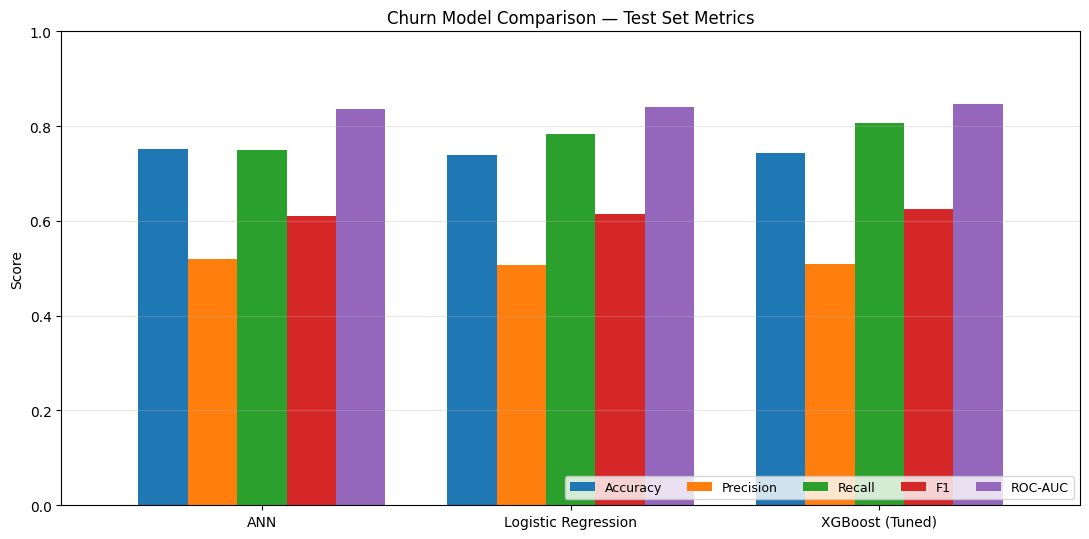

In [8]:
ax = comp_df.plot(kind='bar', figsize=(11, 5.5), width=0.8)
plt.ylabel('Score')
plt.title('Churn Model Comparison — Test Set Metrics')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right', ncol=5, fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Confusion Matrices

Derived from each model's own classification report (support: 1,035 No-Churn / 374 Churn in the test set).

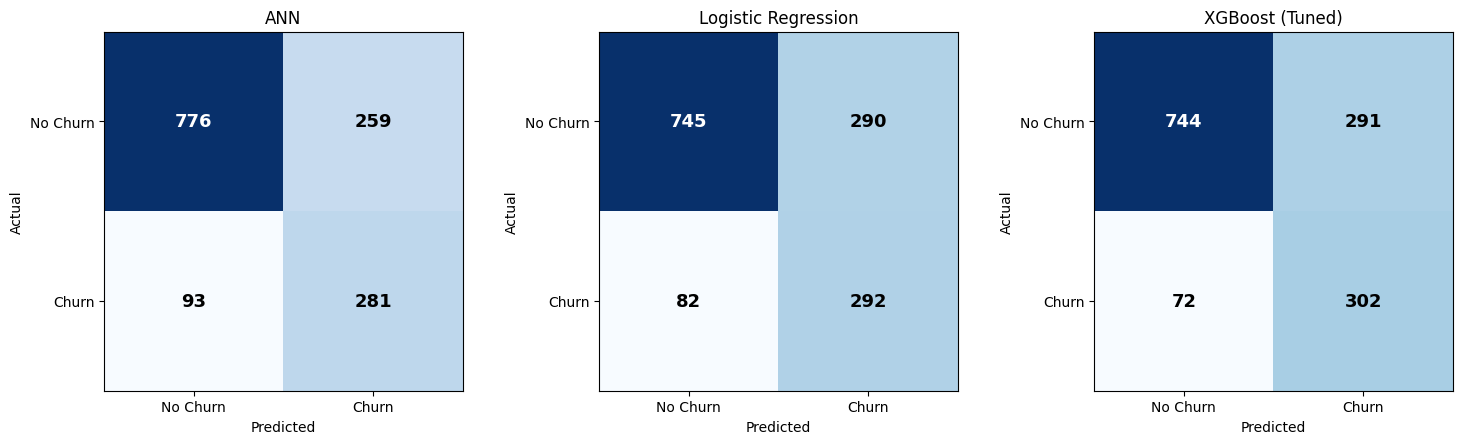

In [9]:
confusion_matrices = {
    'ANN':                 np.array([[776, 259], [93, 281]]),
    'Logistic Regression': np.array([[745, 290], [82, 292]]),
    'XGBoost (Tuned)':     np.array([[744, 291], [72, 302]]),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=13, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Churn', 'Churn']); ax.set_yticklabels(['No Churn', 'Churn'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 4. Churners Actually Caught (Recall) vs Ranking Quality (ROC-AUC)

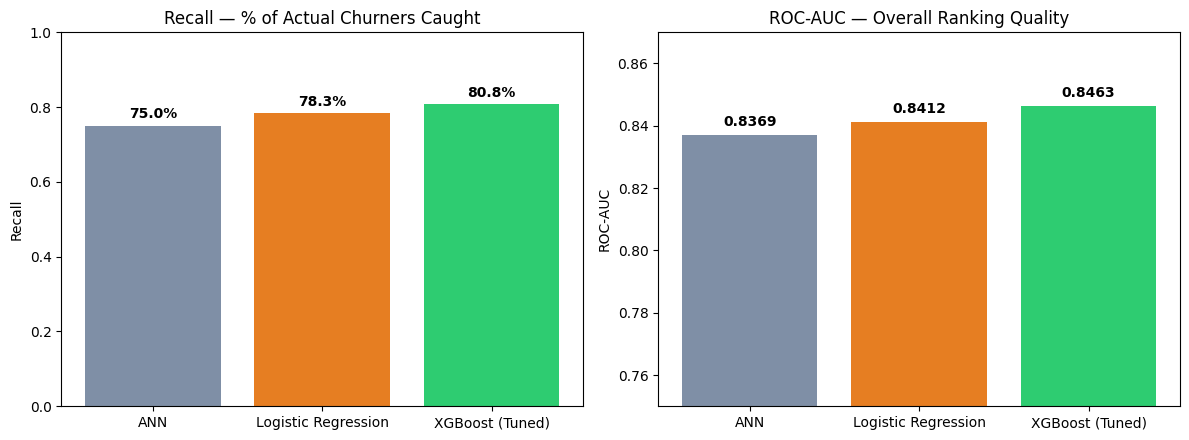

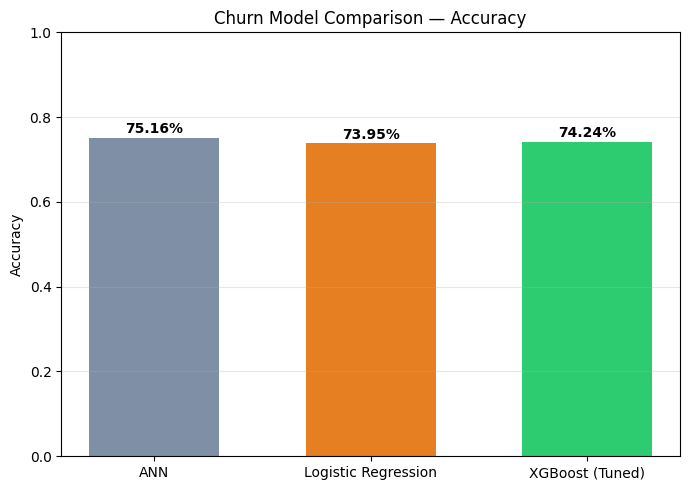

In [13]:


accuracy = {
    'ANN': 0.7516,
    'Logistic Regression': 0.7395,
    'XGBoost (Tuned)': 0.7424,
}

models = list(accuracy.keys())
scores = list(accuracy.values())
colors = ['#7f8fa6', '#e67e22', '#2ecc71']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, scores, color=colors, width=0.6)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.01, f'{score:.2%}',
              ha='center', fontweight='bold')

plt.ylabel('Accuracy')
plt.title('Churn Model Comparison — Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

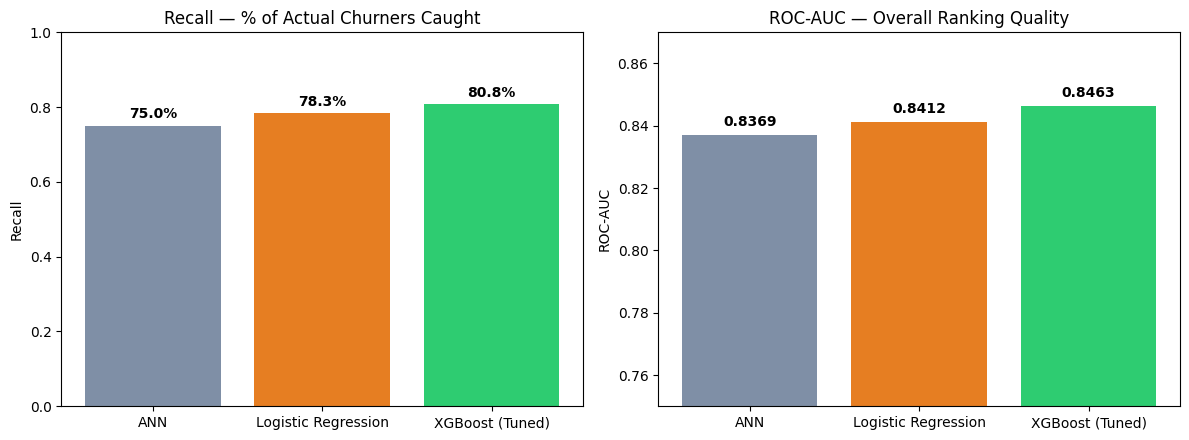

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

models = list(metrics.keys())
recalls = [metrics[m]['Recall'] for m in models]
aucs = [metrics[m]['ROC-AUC'] for m in models]
colors = ['#7f8fa6', '#e67e22', '#2ecc71']

axes[0].bar(models, recalls, color=colors)
axes[0].set_ylim(0, 1); axes[0].set_title('Recall — % of Actual Churners Caught')
axes[0].set_ylabel('Recall')
for i, v in enumerate(recalls):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

axes[1].bar(models, aucs, color=colors)
axes[1].set_ylim(0.75, 0.87); axes[1].set_title('ROC-AUC — Overall Ranking Quality')
axes[1].set_ylabel('ROC-AUC')
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

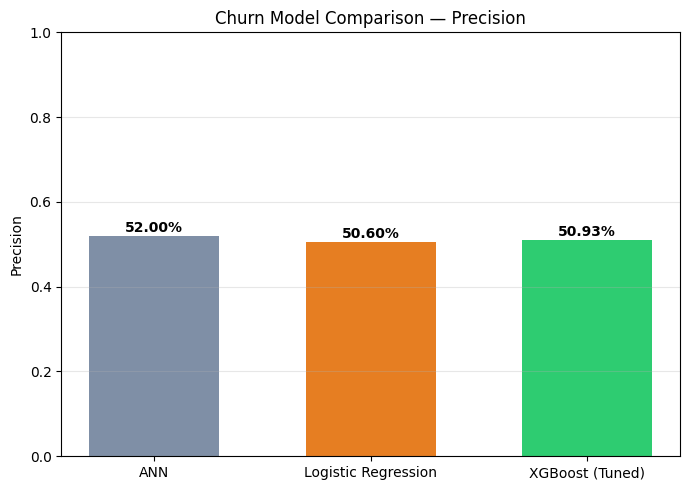

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

precision = {
    'ANN': 0.52,
    'Logistic Regression': 0.5060,
    'XGBoost (Tuned)': 0.5093,
}

models = list(precision.keys())
scores = list(precision.values())
colors = ['#7f8fa6', '#e67e22', '#2ecc71']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, scores, color=colors, width=0.6)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.01, f'{score:.2%}',
              ha='center', fontweight='bold')

plt.ylabel('Precision')
plt.title('Churn Model Comparison — Precision')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Takeaways

**XGBoost (Tuned) wins on the two metrics that matter most for churn:**
- **Highest recall (80.75%)** — catches 302 of 374 actual churners in the test set, more than ANN (281) or Logistic Regression (292). For a retention use case, a missed churner is a lost customer with zero chance to intervene, so this is the metric to optimize for.
- **Highest ROC-AUC (0.8463)** — best at ranking customers by risk overall, which matters if the app produces a prioritized "who to call first" list rather than a flat yes/no.

**Logistic Regression is a strong, cheap baseline** — close behind XGBoost on Recall (78.3%) and ROC-AUC (0.8412), with a fraction of the training/tuning cost. Worth keeping in the writeup as evidence the problem doesn't *require* a complex model — but XGBoost still edges it out and adds feature-importance/SHAP interpretability that logistic coefficients only partially match.

**ANN has the highest raw accuracy (75.16%)** but the lowest recall of the three (75%) and lowest ROC-AUC (0.8369) — it's more conservative about flagging churn, which pushes accuracy up (favoring the majority class) at the direct cost of catching fewer real churners. For this specific business problem, that's the wrong trade-off.
